### **assingment** 4


In [30]:
!pip install wandb --quiet

## Auth & Data Download

In [31]:
!pip install kaggle --quiet

import os, json, wandb
from google.colab import userdata

os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')
wandb.login()

kaggle_creds = {"username": "guramgzobava", "key": "c2913058682cd070fbd0714797e1f0b3"}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d msambare/fer2013 --force
!unzip -o -q fer2013.zip -d fer2013_data

print("Done:", os.listdir('fer2013_data'))

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 83.1MB/s]

Done: ['test', 'train']


## Importsy

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load & Explore Data

In [33]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

emotion_labels = {0:'Angry', 1:'Disgust', 2:'Fear', 3:'Happy', 4:'Sad', 5:'Surprise', 6:'Neutral'}

# Check what's inside
train_dir = 'fer2013_data/train'
test_dir  = 'fer2013_data/test'

print("Train folders:", os.listdir(train_dir))
print("Test folders:",  os.listdir(test_dir))

# Count images per class
for split, path in [('TRAIN', train_dir), ('TEST', test_dir)]:
    total = 0
    for cls in os.listdir(path):
        n = len(os.listdir(os.path.join(path, cls)))
        print(f"  {split} | {cls}: {n}")
        total += n
    print(f"  {split} TOTAL: {total}\n")

Train folders: ['fear', 'angry', 'sad', 'disgust', 'happy', 'surprise', 'neutral']
Test folders: ['fear', 'angry', 'sad', 'disgust', 'happy', 'surprise', 'neutral']
  TRAIN | fear: 4097
  TRAIN | angry: 3995
  TRAIN | sad: 4830
  TRAIN | disgust: 436
  TRAIN | happy: 7215
  TRAIN | surprise: 3171
  TRAIN | neutral: 4965
  TRAIN TOTAL: 28709

  TEST | fear: 1024
  TEST | angry: 958
  TEST | sad: 1247
  TEST | disgust: 111
  TEST | happy: 1774
  TEST | surprise: 831
  TEST | neutral: 1233
  TEST TOTAL: 7178



##  Visualize Sample Images

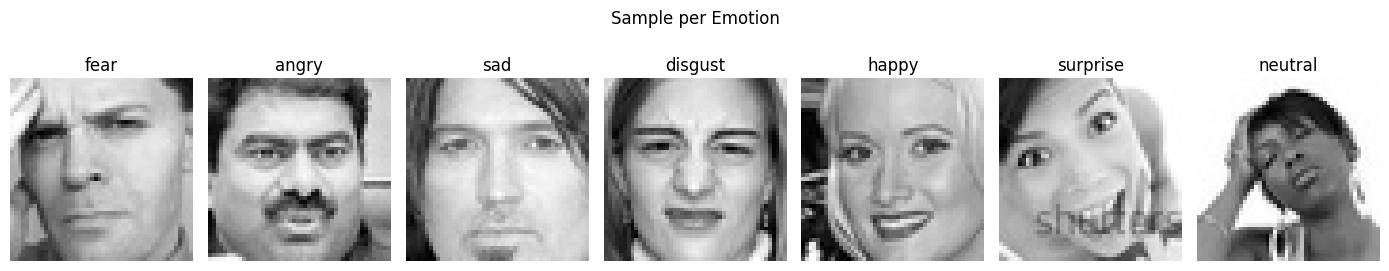

In [34]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 7, figsize=(14, 3))
for i, emotion in enumerate(os.listdir(train_dir)):
    img_path = os.path.join(train_dir, emotion, os.listdir(os.path.join(train_dir, emotion))[0])
    img = Image.open(img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(emotion)
    axes[i].axis('off')
plt.suptitle('Sample per Emotion')
plt.tight_layout()
plt.show()

## Splits & DataLoaders

In [35]:
train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
val_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=val_transform)

# Use 20% of train as validation
val_size   = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.dataset.classes}")

Train: 22968, Val: 5741, Test: 7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Training & Evaluation Functions

In [36]:
import wandb
import os
from google.colab import userdata

os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')
wandb.login()
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), 100. * correct / total, all_preds, all_labels


def run_experiment(model, config, experiment_name):
    run = wandb.init(
        project="fer2013-facial-expression",
        name=experiment_name,
        config=config,
        reinit=True
    )

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if config['optimizer'] == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config.get('weight_decay', 0))
    elif config['optimizer'] == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9, weight_decay=config.get('weight_decay', 0))

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5) if config.get('scheduler') else None

    # Forward check
    sample_input = next(iter(train_loader))[0][:4].to(device)
    with torch.no_grad():
        sample_out = model(sample_input)
    print(f"[{experiment_name}] Forward check — output shape: {sample_out.shape}")

    best_val_acc = 0

    for epoch in range(config['epochs']):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        if scheduler:
            scheduler.step()

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]['lr']
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'/content/{experiment_name}_best.pth')

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{config['epochs']}] Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    # Test evaluation
    model.load_state_dict(torch.load(f'/content/{experiment_name}_best.pth'))
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    ax.set_title(f'Confusion Matrix — {experiment_name}')
    wandb.log({
        "test_acc": test_acc,
        "test_loss": test_loss,
        "best_val_acc": best_val_acc,
        "confusion_matrix": wandb.Image(fig)
    })
    plt.close()

    print(f"\n[{experiment_name}] FINAL TEST ACC: {test_acc:.2f}%")
    print(classification_report(test_labels, test_preds, target_names=list(emotion_labels.values())))

    wandb.finish()
    return model, test_acc

## backward check


In [38]:
# ===== BACKWARD CHECK =====

def backward_check(model, model_name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Get one batch
    sample_input, sample_labels = next(iter(train_loader))
    sample_input  = sample_input.to(device)
    sample_labels = sample_labels.to(device)

    # Forward pass
    output = model(sample_input)
    loss   = criterion(output, sample_labels)

    # Backward pass
    loss.backward()

    # Check every parameter has a gradient
    all_good = True
    for name, param in model.named_parameters():
        if param.requires_grad:
            if param.grad is None:
                print(f"   NO GRADIENT: {name}")
                all_good = False
            elif param.grad.abs().sum().item() == 0:
                print(f"    ZERO GRADIENT: {name}")
                all_good = False
            else:
                print(f"   OK: {name} | grad norm: {param.grad.norm().item():.6f}")

    if all_good:
        print(f"\n[{model_name}]  Backward check PASSED — all gradients flowing correctly\n")
    else:
        print(f"\n[{model_name}]  Backward check FAILED — some gradients missing\n")

print("="*60)
print("BACKWARD CHECKS")
print("="*60)
backward_check(TinyMLP(),      "TinyMLP")
backward_check(SmallCNN(),     "SmallCNN")
backward_check(DeepCNN(),      "DeepCNN")
backward_check(ResNetMini(),   "ResNetMini")

BACKWARD CHECKS
   OK: net.1.weight | grad norm: 1.240340
   OK: net.1.bias | grad norm: 0.065962
   OK: net.3.weight | grad norm: 0.360906
   OK: net.3.bias | grad norm: 0.193161

[TinyMLP]  Backward check PASSED — all gradients flowing correctly

   OK: features.0.weight | grad norm: 0.018982
   OK: features.0.bias | grad norm: 0.013662
   OK: features.3.weight | grad norm: 0.112560
   OK: features.3.bias | grad norm: 0.037909
   OK: classifier.1.weight | grad norm: 0.752469
   OK: classifier.1.bias | grad norm: 0.091029
   OK: classifier.4.weight | grad norm: 0.151956
   OK: classifier.4.bias | grad norm: 0.233551

[SmallCNN]  Backward check PASSED — all gradients flowing correctly

   OK: features.0.weight | grad norm: 0.241950
   OK: features.0.bias | grad norm: 0.000000
   OK: features.1.weight | grad norm: 0.030048
   OK: features.1.bias | grad norm: 0.019240
   OK: features.4.weight | grad norm: 0.833654
   OK: features.4.bias | grad norm: 0.000000
   OK: features.5.weight | gr

## Architecture 1: TinyMLP (Intentional Underfit)

In [14]:
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(48*48, 128),
            nn.ReLU(),
            nn.Linear(128, 7)
        )
    def forward(self, x):
        return self.net(x)

config_mlp = {
    'architecture': 'TinyMLP',
    'lr': 0.001,
    'epochs': 20,
    'optimizer': 'adam',
    'weight_decay': 0,
    'scheduler': False,
    'batch_size': 64,
    'notes': 'Baseline — intentionally underfitting, no spatial features'
}
model_mlp = TinyMLP()
model_mlp, acc_mlp = run_experiment(model_mlp, config_mlp, "arch1_tiny_mlp")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[arch1_tiny_mlp] Forward check — output shape: torch.Size([4, 7])
Epoch [5/20] Train Loss: 1.5616 Acc: 39.72% | Val Loss: 1.5946 Acc: 37.54%
Epoch [10/20] Train Loss: 1.5070 Acc: 42.01% | Val Loss: 1.5598 Acc: 39.71%
Epoch [15/20] Train Loss: 1.4674 Acc: 43.62% | Val Loss: 1.5740 Acc: 40.85%
Epoch [20/20] Train Loss: 1.4317 Acc: 45.29% | Val Loss: 1.5650 Acc: 40.52%

[arch1_tiny_mlp] FINAL TEST ACC: 41.70%
              precision    recall  f1-score   support

       Angry       0.29      0.24      0.26       958
     Disgust       0.38      0.03      0.05       111
        Fear       0.26      0.32      0.29      1024
       Happy       0.56      0.66      0.60      1774
         Sad       0.39      0.41      0.40      1233
    Surprise       0.36      0.27      0.30      1247
     Neutral       0.54      0.52      0.53       831

    accuracy                           0.42      7178
   macro avg       0.39      0.35      0.35      7178
weighted avg       0.41      0.42      0.41     

best_val_acc,▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁
test_loss,▁
train_acc,▁▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇███
train_loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁
val_acc,▁▄▃▄▄▆▅▇▆▇█▇▇▇█▆▇▇▇█
val_loss,█▇▅▃▃▂▃▂▂▁▁▁▂▁▂▃▂▁▁▁
best_val_acc,40.84654
epoch,20


## Architecture 2: SmallCNN

In [15]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*12*12, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

config_small_cnn = {
    'architecture': 'SmallCNN',
    'lr': 0.001,
    'epochs': 30,
    'optimizer': 'adam',
    'weight_decay': 1e-4,
    'scheduler': True,
    'batch_size': 64,
    'notes': '2 conv layers, dropout 0.3, first real CNN'
}
model_small_cnn = SmallCNN()
model_small_cnn, acc_small_cnn = run_experiment(model_small_cnn, config_small_cnn, "arch2_small_cnn")

[arch2_small_cnn] Forward check — output shape: torch.Size([4, 7])
Epoch [5/30] Train Loss: 1.3534 Acc: 47.53% | Val Loss: 1.3687 Acc: 47.24%
Epoch [10/30] Train Loss: 1.2363 Acc: 52.47% | Val Loss: 1.2866 Acc: 51.11%
Epoch [15/30] Train Loss: 1.1453 Acc: 56.21% | Val Loss: 1.2281 Acc: 53.09%
Epoch [20/30] Train Loss: 1.1074 Acc: 57.70% | Val Loss: 1.2220 Acc: 53.77%
Epoch [25/30] Train Loss: 1.0584 Acc: 60.00% | Val Loss: 1.2090 Acc: 54.97%
Epoch [30/30] Train Loss: 1.0228 Acc: 61.55% | Val Loss: 1.2393 Acc: 54.83%

[arch2_small_cnn] FINAL TEST ACC: 55.98%
              precision    recall  f1-score   support

       Angry       0.44      0.46      0.45       958
     Disgust       0.64      0.29      0.40       111
        Fear       0.46      0.28      0.35      1024
       Happy       0.74      0.81      0.77      1774
         Sad       0.50      0.53      0.51      1233
    Surprise       0.41      0.46      0.43      1247
     Neutral       0.71      0.72      0.71       831

  

best_val_acc,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▂▁
test_acc,▁
test_loss,▁
train_acc,▁▃▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████
train_loss,█▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
val_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂
best_val_acc,55.12977
epoch,30


## Architecture 3: DeepCNN (No Regularization → Overfit)

In [16]:
class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),    nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*3*3, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 7)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

config_deep_overfit = {
    'architecture': 'DeepCNN',
    'lr': 0.001,
    'epochs': 40,
    'optimizer': 'adam',
    'weight_decay': 0,
    'scheduler': False,
    'batch_size': 64,
    'notes': 'Deep CNN no regularization — intentional overfit demonstration'
}
model_deep_overfit = DeepCNN()
model_deep_overfit, acc_deep_overfit = run_experiment(model_deep_overfit, config_deep_overfit, "arch3_deep_cnn_overfit")

[arch3_deep_cnn_overfit] Forward check — output shape: torch.Size([4, 7])
Epoch [5/40] Train Loss: 1.2995 Acc: 49.94% | Val Loss: 1.3020 Acc: 49.96%
Epoch [10/40] Train Loss: 1.1672 Acc: 55.70% | Val Loss: 1.2065 Acc: 54.73%
Epoch [15/40] Train Loss: 1.0745 Acc: 59.67% | Val Loss: 1.1673 Acc: 55.53%
Epoch [20/40] Train Loss: 0.9987 Acc: 62.73% | Val Loss: 1.1251 Acc: 58.53%
Epoch [25/40] Train Loss: 0.9253 Acc: 65.83% | Val Loss: 1.0971 Acc: 59.35%
Epoch [30/40] Train Loss: 0.8528 Acc: 68.36% | Val Loss: 1.1185 Acc: 58.96%
Epoch [35/40] Train Loss: 0.7968 Acc: 70.69% | Val Loss: 1.1064 Acc: 59.64%
Epoch [40/40] Train Loss: 0.7422 Acc: 72.86% | Val Loss: 1.1311 Acc: 59.52%

[arch3_deep_cnn_overfit] FINAL TEST ACC: 62.83%
              precision    recall  f1-score   support

       Angry       0.51      0.55      0.53       958
     Disgust       0.72      0.12      0.20       111
        Fear       0.47      0.42      0.44      1024
       Happy       0.80      0.88      0.84      1774

best_val_acc,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁
test_loss,▁
train_acc,▁▃▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████
train_loss,█▆▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▄▅▅▆▆▆▇▆▇▇▇▇▇▇▇▇███████████████████████
val_loss,█▅▄▄▃▃▃▂▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▂
best_val_acc,60.39018
epoch,40


## Architecture 3b: DeepCNN (Regularized)

In [17]:
config_deep_reg = {
    'architecture': 'DeepCNN',
    'lr': 0.0005,
    'epochs': 40,
    'optimizer': 'adam',
    'weight_decay': 1e-3,
    'scheduler': True,
    'batch_size': 64,
    'notes': 'Same DeepCNN with L2 + scheduler — fix overfit'
}
model_deep_reg = DeepCNN()
model_deep_reg, acc_deep_reg = run_experiment(model_deep_reg, config_deep_reg, "arch3_deep_cnn_regularized")

[arch3_deep_cnn_regularized] Forward check — output shape: torch.Size([4, 7])
Epoch [5/40] Train Loss: 1.2629 Acc: 52.10% | Val Loss: 1.2559 Acc: 51.40%
Epoch [10/40] Train Loss: 1.1461 Acc: 57.11% | Val Loss: 1.1597 Acc: 56.66%
Epoch [15/40] Train Loss: 1.0244 Acc: 61.86% | Val Loss: 1.0732 Acc: 59.62%
Epoch [20/40] Train Loss: 0.9541 Acc: 64.77% | Val Loss: 1.1230 Acc: 58.75%
Epoch [25/40] Train Loss: 0.8430 Acc: 69.19% | Val Loss: 1.0593 Acc: 61.19%
Epoch [30/40] Train Loss: 0.7738 Acc: 71.50% | Val Loss: 1.0840 Acc: 60.69%
Epoch [35/40] Train Loss: 0.6888 Acc: 75.03% | Val Loss: 1.1187 Acc: 60.90%
Epoch [40/40] Train Loss: 0.6482 Acc: 76.50% | Val Loss: 1.1715 Acc: 60.95%

[arch3_deep_cnn_regularized] FINAL TEST ACC: 64.03%
              precision    recall  f1-score   support

       Angry       0.54      0.58      0.56       958
     Disgust       0.78      0.16      0.27       111
        Fear       0.52      0.35      0.42      1024
       Happy       0.84      0.84      0.84  

best_val_acc,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,█████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁
test_loss,▁
train_acc,▁▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████
train_loss,█▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▂▄▅▅▆▅▆▆▇▇▇▇▇▇▇▇█▇▇▇███████████████████
val_loss,█▇▅▄▄▃▄▃▃▂▂▂▂▂▁▁▂▁▁▂▁▁▁▁▁▁▁▂▁▁▂▂▂▂▂▂▂▂▂▃
best_val_acc,61.69657
epoch,40


## Architecture 4: ResNetMini with SGD

In [18]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.block(x))


class ResNetMini(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.layer1 = nn.Sequential(ResidualBlock(64), nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(ResidualBlock(64), nn.MaxPool2d(2))
        self.layer3 = nn.Sequential(ResidualBlock(64), nn.MaxPool2d(2))
        self.head   = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 7))
    def forward(self, x):
        return self.head(self.layer3(self.layer2(self.layer1(self.stem(x)))))

config_resnet_sgd = {
    'architecture': 'ResNetMini',
    'lr': 0.01,
    'epochs': 40,
    'optimizer': 'sgd',
    'weight_decay': 1e-4,
    'scheduler': True,
    'batch_size': 64,
    'notes': 'Residual blocks, SGD with momentum'
}
model_resnet_sgd = ResNetMini()
model_resnet_sgd, acc_resnet_sgd = run_experiment(model_resnet_sgd, config_resnet_sgd, "arch4_resnet_mini_sgd")

[arch4_resnet_mini_sgd] Forward check — output shape: torch.Size([4, 7])
Epoch [5/40] Train Loss: 1.3564 Acc: 47.81% | Val Loss: 1.4574 Acc: 44.80%
Epoch [10/40] Train Loss: 1.1252 Acc: 57.51% | Val Loss: 1.2121 Acc: 54.15%
Epoch [15/40] Train Loss: 0.9797 Acc: 62.73% | Val Loss: 1.2257 Acc: 56.24%
Epoch [20/40] Train Loss: 0.9291 Acc: 64.62% | Val Loss: 1.1152 Acc: 58.98%
Epoch [25/40] Train Loss: 0.8301 Acc: 68.73% | Val Loss: 1.1134 Acc: 59.22%
Epoch [30/40] Train Loss: 0.7856 Acc: 70.76% | Val Loss: 1.1608 Acc: 57.74%
Epoch [35/40] Train Loss: 0.7173 Acc: 73.56% | Val Loss: 1.1158 Acc: 60.48%
Epoch [40/40] Train Loss: 0.6844 Acc: 74.76% | Val Loss: 1.1180 Acc: 61.47%

[arch4_resnet_mini_sgd] FINAL TEST ACC: 62.91%
              precision    recall  f1-score   support

       Angry       0.58      0.54      0.55       958
     Disgust       0.57      0.39      0.46       111
        Fear       0.47      0.40      0.43      1024
       Happy       0.79      0.87      0.83      1774
 

best_val_acc,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,█████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁
test_loss,▁
train_acc,▁▂▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▇▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▃▅▄▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████▇▇███▇████████▇█
val_loss,██▆▄▅▄▃▃▃▂▂▂▂▂▃▂▂▁▁▁▁▁▂▁▁▂▁▁▁▂▁▁▁▁▂▁▁▁▂▂
best_val_acc,61.62689
epoch,40


## Architecture 4b: ResNetMini with Adam

In [19]:
config_resnet_adam = {
    'architecture': 'ResNetMini',
    'lr': 0.0003,
    'epochs': 40,
    'optimizer': 'adam',
    'weight_decay': 1e-4,
    'scheduler': True,
    'batch_size': 64,
    'notes': 'Same ResNetMini Adam optimizer — compare vs SGD'
}
model_resnet_adam = ResNetMini()
model_resnet_adam, acc_resnet_adam = run_experiment(model_resnet_adam, config_resnet_adam, "arch4_resnet_mini_adam")

[arch4_resnet_mini_adam] Forward check — output shape: torch.Size([4, 7])
Epoch [5/40] Train Loss: 1.1832 Acc: 55.57% | Val Loss: 1.3030 Acc: 52.46%
Epoch [10/40] Train Loss: 1.0575 Acc: 60.05% | Val Loss: 1.2948 Acc: 50.83%
Epoch [15/40] Train Loss: 0.9458 Acc: 64.61% | Val Loss: 1.1355 Acc: 57.10%
Epoch [20/40] Train Loss: 0.8950 Acc: 66.73% | Val Loss: 1.1024 Acc: 59.10%
Epoch [25/40] Train Loss: 0.8304 Acc: 69.63% | Val Loss: 1.1086 Acc: 59.52%
Epoch [30/40] Train Loss: 0.8055 Acc: 70.34% | Val Loss: 1.1174 Acc: 59.15%
Epoch [35/40] Train Loss: 0.7650 Acc: 71.85% | Val Loss: 1.0685 Acc: 61.16%
Epoch [40/40] Train Loss: 0.7472 Acc: 72.58% | Val Loss: 1.0940 Acc: 60.65%

[arch4_resnet_mini_adam] FINAL TEST ACC: 62.76%
              precision    recall  f1-score   support

       Angry       0.54      0.55      0.55       958
     Disgust       0.65      0.32      0.42       111
        Fear       0.51      0.37      0.43      1024
       Happy       0.85      0.83      0.84      1774

best_val_acc,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,█████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁
test_loss,▁
train_acc,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▄▄▅▆▅▆▆▅▇▇▇▇▇▇▇▇▇▇▇███▇████▇█████▇████
val_loss,█▆▅▅▄▃▄▃▃▄▂▂▂▂▂▂▂▂▁▂▁▁▁▁▂▁▁▁▂▂▁▁▁▁▁▂▁▁▁▂
best_val_acc,62.25396
epoch,40


## Results Summary


===== RESULTS SUMMARY =====
DeepCNN (regularized)         : 64.03%
ResNetMini SGD                : 62.91%
DeepCNN (overfit)             : 62.83%
ResNetMini Adam               : 62.76%
SmallCNN                      : 55.98%
TinyMLP (underfit)            : 41.70%


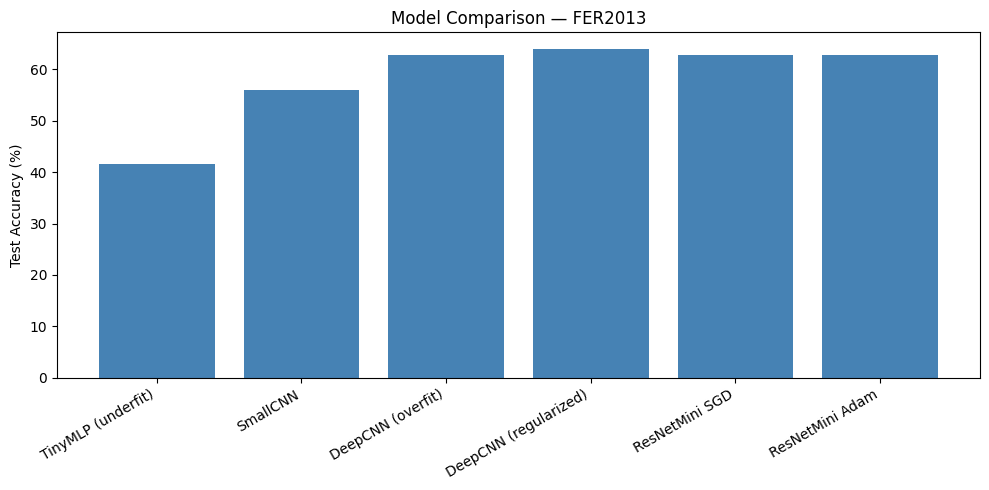

In [20]:
results = {
    'TinyMLP (underfit)':    acc_mlp,
    'SmallCNN':              acc_small_cnn,
    'DeepCNN (overfit)':     acc_deep_overfit,
    'DeepCNN (regularized)': acc_deep_reg,
    'ResNetMini SGD':        acc_resnet_sgd,
    'ResNetMini Adam':       acc_resnet_adam,
}

print("\n===== RESULTS SUMMARY =====")
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name:30s}: {acc:.2f}%")

run = wandb.init(project="fer2013-facial-expression", name="summary_comparison", reinit=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(results.keys(), results.values(), color='steelblue')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Model Comparison — FER2013')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
wandb.log({"model_comparison": wandb.Image(fig)})
plt.show()
wandb.finish()